In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Chargement du dataset nettoyé
df = pd.read_csv('../data/processed/dataset_nettoye.csv')

print("Dataset chargé !")
print(f"{df.shape[0]} lignes × {df.shape[1]} colonnes")

Dataset chargé !
5000 lignes × 34 colonnes


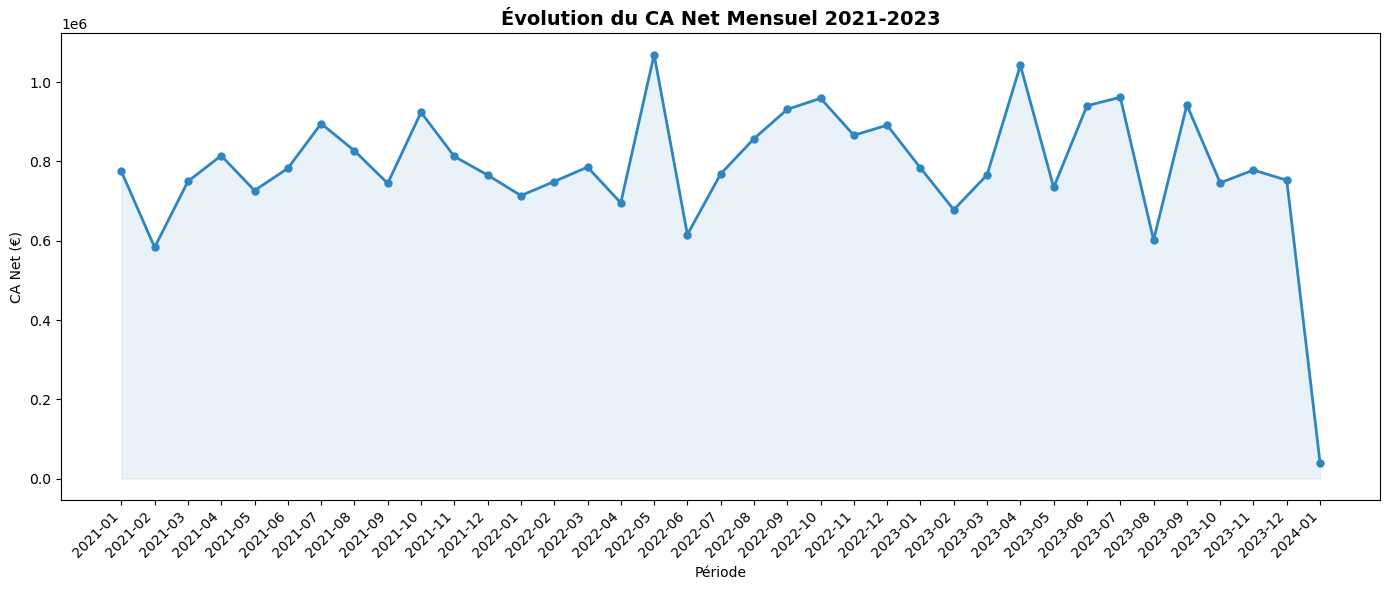

Graphique sauvegardé !


In [3]:
# Grouper le CA par année et mois
ca_mensuel = df.groupby(['annee', 'mois'])['montant_net_eur'].sum().reset_index()
ca_mensuel['periode'] = ca_mensuel['annee'].astype(str) + '-' + ca_mensuel['mois'].astype(str).str.zfill(2)
ca_mensuel = ca_mensuel.sort_values('periode')

# Graphique
plt.figure(figsize=(14, 6))
plt.plot(ca_mensuel['periode'], ca_mensuel['montant_net_eur'],
         marker='o', color='#2E86C1', linewidth=2, markersize=5)
plt.fill_between(range(len(ca_mensuel)), ca_mensuel['montant_net_eur'], 
                 alpha=0.1, color='#2E86C1')
plt.xticks(range(len(ca_mensuel)), ca_mensuel['periode'], rotation=45, ha='right')
plt.title("Évolution du CA Net Mensuel 2021-2023", fontsize=14, fontweight='bold')
plt.xlabel("Période")
plt.ylabel("CA Net (€)")
plt.tight_layout()
plt.savefig('../outputs/ca_mensuel.png', dpi=300)
plt.show()
print("Graphique sauvegardé !")

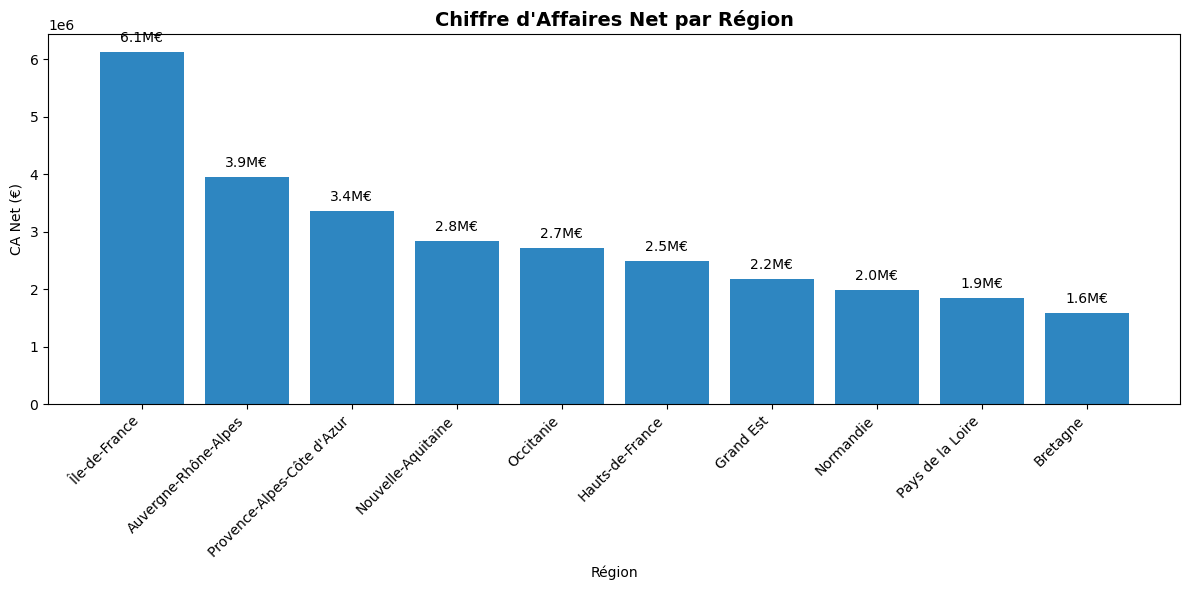

Graphique sauvegardé !


In [4]:
# CA total par région
ca_region = df.groupby('region')['montant_net_eur'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
bars = plt.bar(ca_region['region'], ca_region['montant_net_eur'], color='#2E86C1')
plt.bar_label(bars, labels=[f"{v/1e6:.1f}M€" for v in ca_region['montant_net_eur']], padding=5)
plt.title("Chiffre d'Affaires Net par Région", fontsize=14, fontweight='bold')
plt.xlabel("Région")
plt.ylabel("CA Net (€)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/ca_region.png', dpi=300)
plt.show()
print("Graphique sauvegardé !")

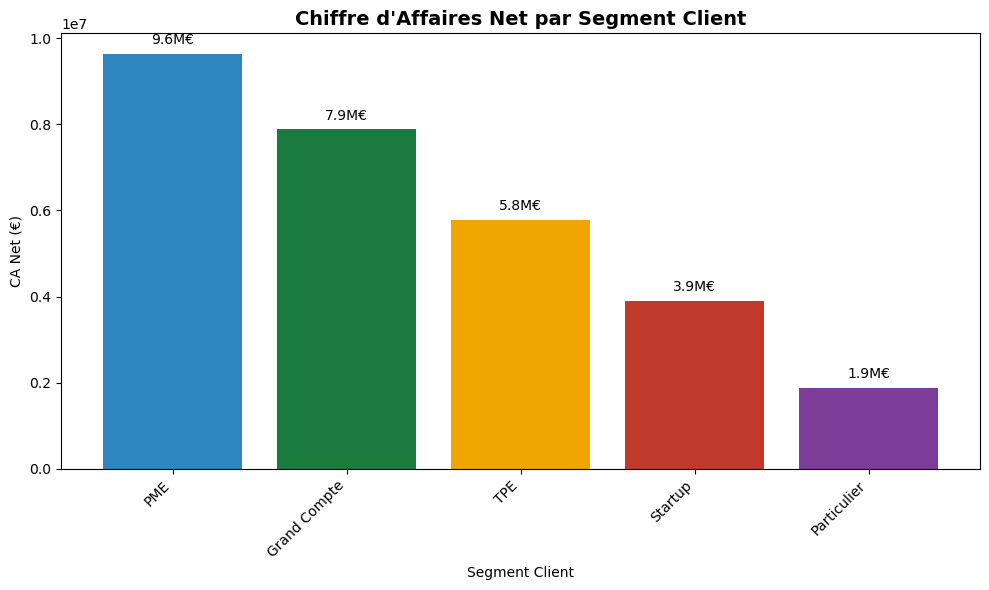

Graphique sauvegardé !


In [5]:
# CA par segment client
ca_segment = df.groupby('segment_client')['montant_net_eur'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
colors = ['#2E86C1', '#1B7A3E', '#F0A500', '#C0392B', '#7D3C98']
bars = plt.bar(ca_segment['segment_client'], ca_segment['montant_net_eur'], color=colors)
plt.bar_label(bars, labels=[f"{v/1e6:.1f}M€" for v in ca_segment['montant_net_eur']], padding=5)
plt.title("Chiffre d'Affaires Net par Segment Client", fontsize=14, fontweight='bold')
plt.xlabel("Segment Client")
plt.ylabel("CA Net (€)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/ca_segment.png', dpi=300)
plt.show()
print("Graphique sauvegardé !")

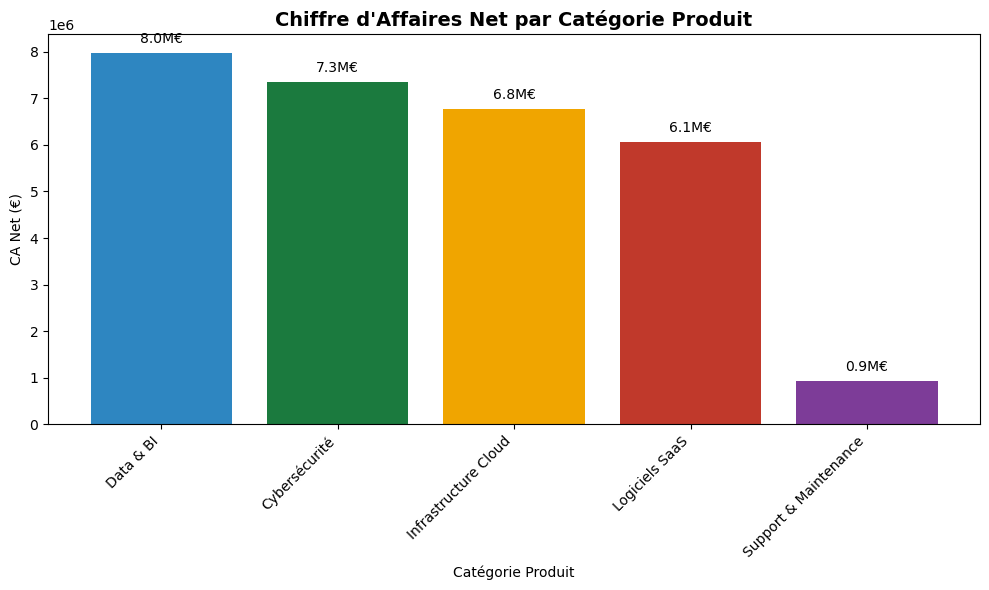

Graphique sauvegardé !


In [6]:
# CA par catégorie produit
ca_produit = df.groupby('categorie_produit')['montant_net_eur'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
colors = ['#2E86C1', '#1B7A3E', '#F0A500', '#C0392B', '#7D3C98']
bars = plt.bar(ca_produit['categorie_produit'], ca_produit['montant_net_eur'], color=colors)
plt.bar_label(bars, labels=[f"{v/1e6:.1f}M€" for v in ca_produit['montant_net_eur']], padding=5)
plt.title("Chiffre d'Affaires Net par Catégorie Produit", fontsize=14, fontweight='bold')
plt.xlabel("Catégorie Produit")
plt.ylabel("CA Net (€)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/ca_produit.png', dpi=300)
plt.show()
print("Graphique sauvegardé !")

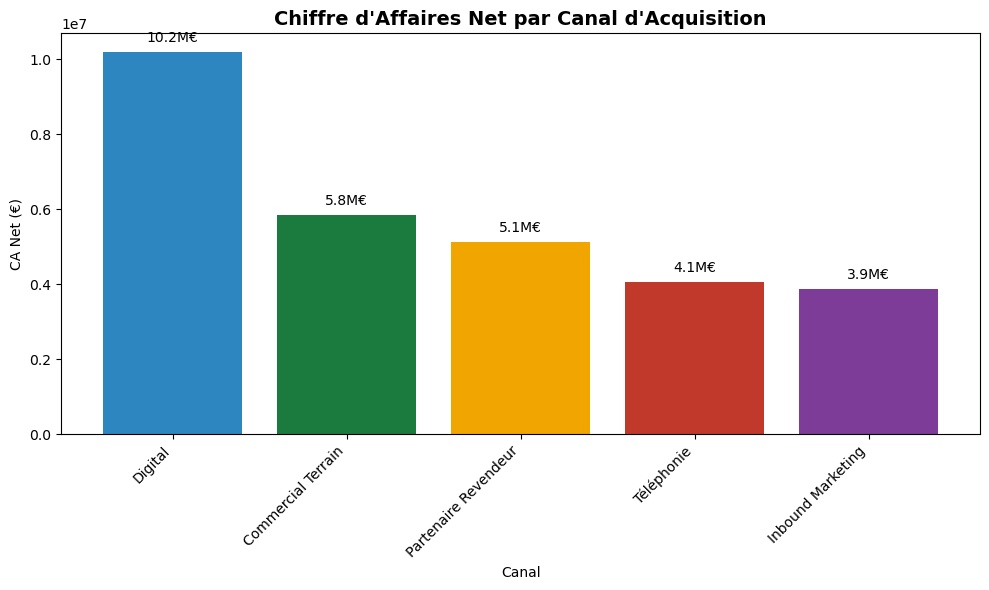

Graphique sauvegardé !


In [7]:
# CA par canal d'acquisition
ca_canal = df.groupby('canal_acquisition')['montant_net_eur'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
colors = ['#2E86C1', '#1B7A3E', '#F0A500', '#C0392B', '#7D3C98']
bars = plt.bar(ca_canal['canal_acquisition'], ca_canal['montant_net_eur'], color=colors)
plt.bar_label(bars, labels=[f"{v/1e6:.1f}M€" for v in ca_canal['montant_net_eur']], padding=5)
plt.title("Chiffre d'Affaires Net par Canal d'Acquisition", fontsize=14, fontweight='bold')
plt.xlabel("Canal")
plt.ylabel("CA Net (€)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/ca_canal.png', dpi=300)
plt.show()
print("Graphique sauvegardé !")

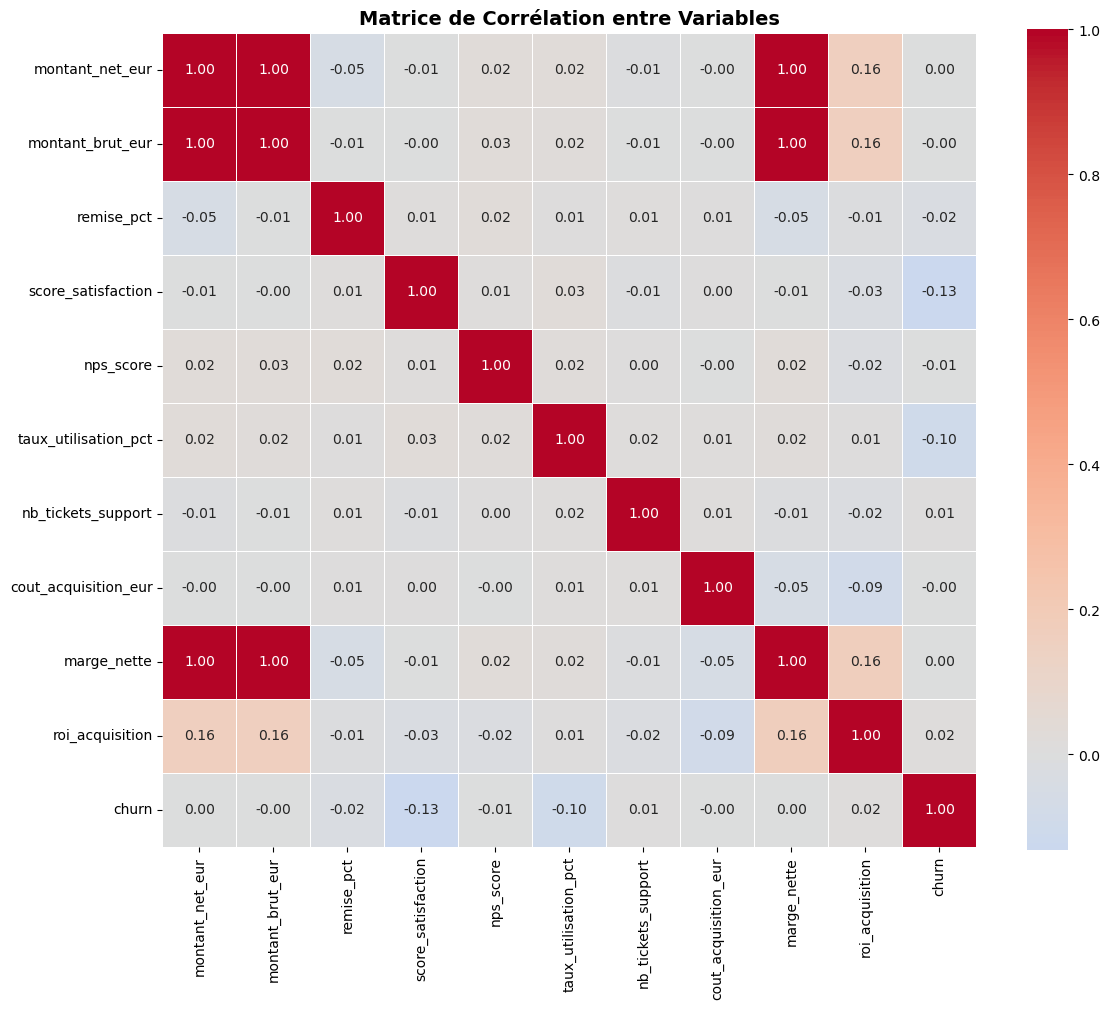

Graphique sauvegardé !


In [9]:
# Sélectionner les colonnes numériques importantes
colonnes_corr = ['montant_net_eur', 'montant_brut_eur', 'remise_pct', 
                 'score_satisfaction', 'nps_score', 'taux_utilisation_pct',
                 'nb_tickets_support', 'cout_acquisition_eur', 'marge_nette', 
                 'roi_acquisition', 'churn']

corr = df[colonnes_corr].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title("Matrice de Corrélation entre Variables", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/matrice_correlation.png', dpi=300)
plt.show()
print("Graphique sauvegardé !")